# 1. Introduction to spatial transcriptomics

*For an ML / maths audience.* Spatial transcriptomics (ST) measures gene expression
while keeping the physical **coordinates** of each spot or cell. So the data is a
high-dimensional signal (expression) attached to points in a plane, plus tissue
structure to exploit. This notebook introduces the **data object**, the **libraries**,
and the basic **workflow** (QC, normalisation, cell types, spatial visualisation) on a
real 10x Xenium kidney dataset. Spatial *methods* and *challenges* follow in notebook 2.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import scanpy as sc, squidpy as sq
import matplotlib.pyplot as plt
import topo_utils as tu
sc.settings.verbosity = 1

/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


## The libraries

- **anndata** - the in-memory data container (`AnnData`).
- **scanpy** - single-cell toolkit: IO, QC, normalisation, clustering, embeddings.
- **squidpy** - the spatial extension: neighbour graphs and spatial statistics.

The whole ecosystem is built around one object, so it is worth understanding its layout.

## The dataset: human kidney Xenium (GSE294965)

An imaging-based, **single-cell** ST assay: individual transcripts are imaged and
assigned to segmented cells, for a fixed **panel** of genes (here 480). The atlas spans
several kidney diseases and controls. See `data/datasets.md`.

In [2]:
adata = sc.read_h5ad(tu.data_path())
print(adata.shape, '= cells x genes')
print('diseases:', dict(adata.obs['Disease'].value_counts()))
print('samples:', adata.obs['sample'].nunique(), '| cell types:', adata.obs['celltype_l1'].nunique())

(3218210, 480) = cells x genes
diseases: {'ANCA': 1573032, 'SLE': 798228, 'GBM': 462735, 'Cntrl': 384215}
samples: 63 | cell types: 30


## The AnnData object

One matrix plus aligned annotations. For an ML reader:

| slot | holds | shape |
| --- | --- | --- |
| `X` | expression (the design matrix) | cells x genes |
| `layers['counts']` | raw counts | cells x genes |
| `obs` | per-cell table (labels, QC) | cells x fields |
| `var` | per-gene table (the panel) | genes x fields |
| `obsm['spatial']` | tissue coordinates | cells x 2 |
| `obsm['X_umap']`, `obsm['X_pca']` | embeddings | cells x d |

In [3]:
print('obsm:', list(adata.obsm.keys()))
print('layers:', list(adata.layers.keys()))
print('panel (var) head:'); print(adata.var.head(3))
print('spatial coords (microns):'); print(adata.obsm['spatial'][:3])

obsm: ['X_pca', 'X_pca_harmony', 'X_umap', 'spatial']
layers: ['counts']
panel (var) head:
      gene_ids    feature_types
ABCC3    ABCC3  Gene Expression
ABR        ABR  Gene Expression
ACKR3    ACKR3  Gene Expression
spatial coords (microns):
[[4221.53306154  884.85878   ]
 [4198.10564     924.251868  ]
 [4556.54075714  577.16478286]]


## Work on one tissue section

The atlas holds many samples on several slides. We analyse **one section** so the tissue
is a single connected piece, and cache it for notebooks 2 and 3.

In [4]:
one = adata.obs['sample'].value_counts().index[0]
sub = adata[adata.obs['sample'] == one].copy()
print('section', one, '->', sub.shape)
sub.write(tu.results_dir() / 'section.h5ad'); print('cached ->', tu.results_dir() / 'section.h5ad')

section X21 -> (220825, 480)


cached -> /data/bonn-epyc/projects/robin/course_0626/st-topo-aware-learning-logml/results/section.h5ad


## Quality control

Xenium is **sparse** (few counts per cell) and uses a **targeted panel**, so QC matters.
Typical per-cell metrics: transcripts detected, genes detected, cell area. Cells that are
too small or nearly empty are usually segmentation artefacts.

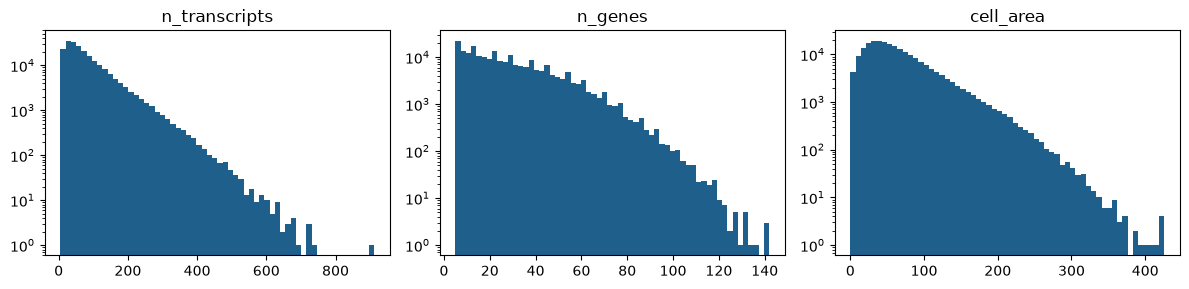

       n_transcripts    n_genes  cell_area
count      220825.00  220825.00  220825.00
mean           81.04      28.12      64.52
std            68.73      19.03      45.03
min             5.00       5.00       0.09
25%            34.00      13.00      32.80
50%            60.00      24.00      53.62
75%           105.00      40.00      84.45
max           912.00     142.00     425.90


In [5]:
qc = [c for c in ['n_transcripts','n_genes','cell_area'] if c in sub.obs]
fig, ax = plt.subplots(1, len(qc), figsize=(4*len(qc), 3))
for a, c in zip(np.atleast_1d(ax), qc):
    a.hist(sub.obs[c], bins=60, color='#1f5f8c'); a.set_title(c); a.set_yscale('log')
plt.tight_layout(); plt.show()
print(sub.obs[qc].describe().round(2))

## Normalisation

The standard recipe is library-size normalisation followed by `log1p`. This object
already ships **log-normalised** values in `X` (and raw counts in `layers['counts']`),
so we only normalise if `X` still looks like counts.

In [6]:
print('X max (log-normalised if small):', round(float(sub.X.max()), 2))
print('counts layer max (raw):', round(float(sub.layers['counts'].max()), 2))
if float(sub.X.max()) > 30:
    sc.pp.normalize_total(sub); sc.pp.log1p(sub); print('normalised')

X max (log-normalised if small): 3.41
counts layer max (raw): 108.0


## Cell types

Cells are annotated (here `celltype_l1`), usually by clustering the expression and
matching clusters to a reference or marker genes. For ML work these labels are the
targets or the covariates you condition on.

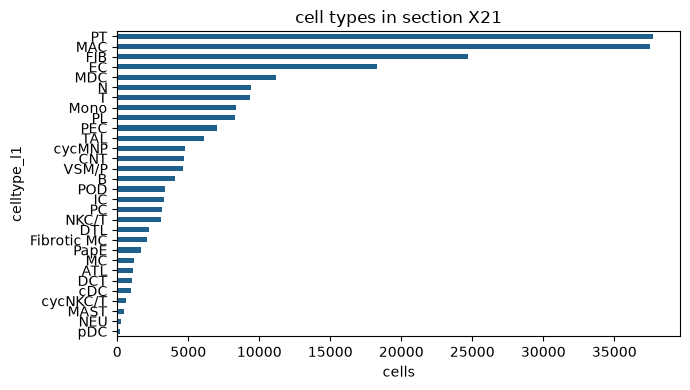

In [7]:
vc = sub.obs['celltype_l1'].value_counts()
fig, axc = plt.subplots(figsize=(7,4)); vc.iloc[::-1].plot.barh(ax=axc, color='#1f5f8c')
axc.set_xlabel('cells'); axc.set_title(f'cell types in section {one}'); plt.tight_layout(); plt.show()

## The defining feature: coordinates

Unlike dissociated scRNA-seq, we can put every cell back in the tissue. Left: the
expression manifold (UMAP). Right: the same cells **in space**. Structure that is invisible
in UMAP (layers, compartments, interfaces) appears in the spatial view.

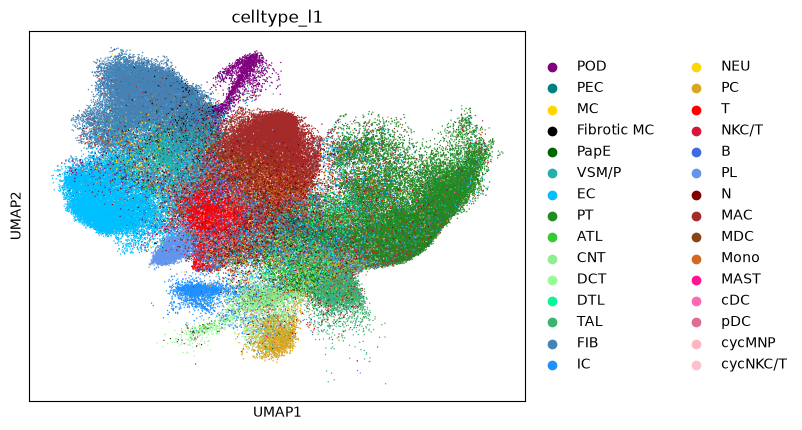

In [8]:
sc.pl.umap(sub, color='celltype_l1', size=4, show=True)

/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


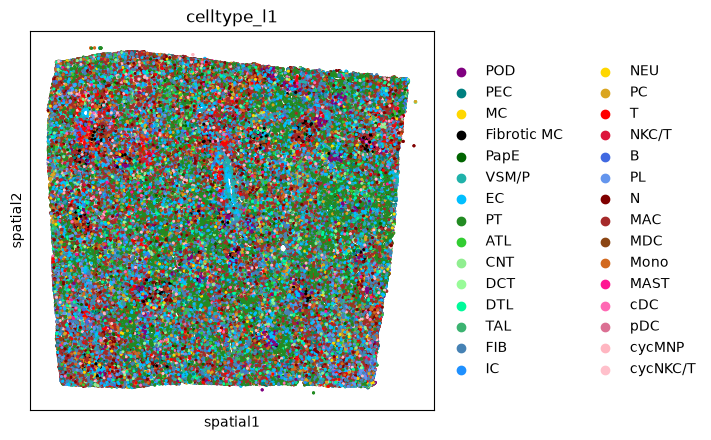

In [9]:
sq.pl.spatial_scatter(sub, color='celltype_l1', shape=None, size=6, figsize=(7,7))

### Recap

We loaded a Xenium section, saw the AnnData layout, ran QC, checked normalisation, looked
at cell types, and plotted cells in tissue space. Next: turning coordinates into spatial
structure (the neighbourhood graph), spatial statistics, domains, communication, and the
challenges that make ST hard.